# Exploratory analyasis on features


### EDA overview and dataset setup

This notebook explores profitability drivers with a focus on when (temporal), where (spatial), and ride-sharing/weather effects. We use two responses:
- `uber_commission` (USD per trip)
- `y_cpm` (USD per mile; commission per mile)

Guidelines we follow:
- Use the full distribution for histograms/percentiles/outlier analysis (no subsample for summary stats).
- Use sampled subsets only for dense plots (scatter/OD flows), and state the sample size.
- Save figures to `./lake/reports/figures/` for inclusion in the report.


#### Derived response definitions
We ensure `y_cpm` is defined consistently before analysis:
- `y_cpm = uber_commission / trip_miles` for trips with `trip_miles > 0.1` (avoid near-zero inflation); otherwise null.
- If a precomputed column `uber_revenue_per_mile` exists, we alias it to `y_cpm` for comparability.


#### Load data and helpers
We read the comprehensive profitability dataset for 2023–2024 if available (union by name). For heavy visuals (scatter/OD flows), we create a reproducible sample. Figures are saved to `./lake/reports/figures/`.


In [3]:
import os
from pyspark.sql import SparkSession, functions as F

# Spark session (reuse from other notebooks if active)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 2")
    .master("local[*]")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "6g")            # leave room for OS/other apps
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "512m")
    .config("spark.memory.fraction", "0.5")
    .getOrCreate()
)


FIG_DIR = "./lake/reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Load unioned comprehensive dataset if present
root = "./lake/comprehensive"
paths = [
    f"{root}/corrected_profitability_2023_*",
    f"{root}/corrected_profitability_2024_*",
]

df_list = []
for p in paths:
    try:
        df_list.append(
            spark.read.option("recursiveFileLookup", "true")
                 .option("pathGlobFilter", "*.parquet").parquet(p)
        )
    except Exception:
        pass

if not df_list:
    raise RuntimeError("No comprehensive datasets found under ./lake/comprehensive/")

df = df_list[0]
for extra in df_list[1:]:
    df = df.unionByName(extra, allowMissingColumns=True)

print("rows:", df.count(), "cols:", len(df.columns))

# Ensure y_cpm exists (alias or derived)
if "y_cpm" not in df.columns:
    if "uber_revenue_per_mile" in df.columns:
        df = df.withColumn("y_cpm", F.col("uber_revenue_per_mile"))
    elif all(c in df.columns for c in ["uber_commission","trip_miles"]):
        df = df.withColumn(
            "y_cpm",
            F.when(F.col("trip_miles") > 0, F.col("uber_commission")/F.col("trip_miles")).otherwise(F.lit(None))
        )
    else:
        raise RuntimeError("Cannot derive y_cpm: missing uber_revenue_per_mile and also missing uber_commission/trip_miles")

if "trip_miles" in df.columns and "log_trip_miles" not in df.columns:
    df = df.withColumn("log_trip_miles", F.log(F.col("trip_miles") + F.lit(1e-6)))


# Helpful small sample for dense plots (only needed columns, avoid heavy shuffle)
SAMPLE_SEED = 42
SAMPLE_SIZE = 200_000
TOTAL = df.count()
SAMPLE_FRAC = min(1.0, SAMPLE_SIZE / max(TOTAL, 1))

sample_cols = [c for c in ["uber_commission", "y_cpm"] if c in df.columns]
if not sample_cols:
    raise RuntimeError("Required columns for sampling not found: uber_commission, y_cpm")

# Prefer random sampling over global orderBy(rand) to reduce shuffle cost
# Also disable Arrow temporarily to avoid Arrow conversion issues on large/mixed schemas
orig_arrow = spark.conf.get("spark.sql.execution.arrow.pyspark.enabled", "true")
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")
try:
    pdf_sample = (df.select(*sample_cols)
                    .sample(False, SAMPLE_FRAC, seed=SAMPLE_SEED)
                    .limit(SAMPLE_SIZE)
                    .toPandas())
finally:
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", orig_arrow)



25/08/31 21:34:50 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: ./lake/comprehensive/corrected_profitability_2023_*.
java.io.FileNotFoundException: File lake/comprehensive/corrected_profitability_2023_* does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala

rows: 302284316 cols: 46


In [4]:
try:
    safe_spark_to_pandas
except NameError:
    def safe_spark_to_pandas(sdf, label: str = "data", sample_frac: float = 1.0, seed: int = 42):
        """
        Safely convert a Spark DataFrame to Pandas, with optional sub-sampling.
        - If sample_frac < 1.0, random-sample rows for speed.
        - If sdf is None or empty, return None.
        """
        if sdf is None:
            return None
        try:
            if sample_frac < 1.0:
                sdf = sdf.sample(withReplacement=False, fraction=sample_frac, seed=seed)
            n = sdf.count()
            if n == 0:
                return None
            pdf = sdf.toPandas()
            return pdf
        except Exception as e:
            print(f"[safe_spark_to_pandas] Failed converting {label}: {e}")
            return None

### 1) Distributions, outliers, and summary percentiles
We analyze full distributions of `uber_commission` and `uber_revenue_per_mile`. We report key percentiles to characterise tails and avoid relying on subsamples for summary stats.


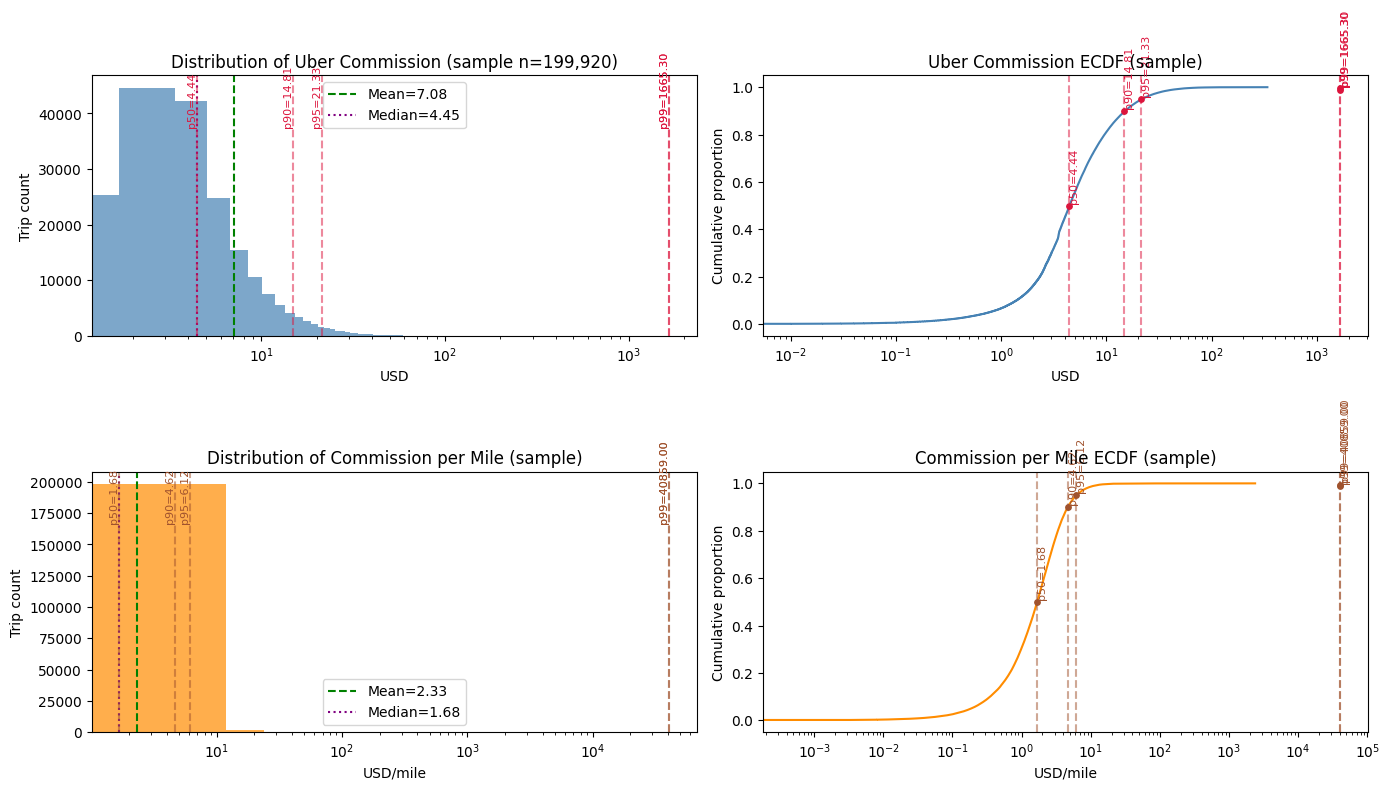

,percentile,uber_commission,y_cpm,commission_mean,commission_median,y_cpm_mean,y_cpm_median
0,0.500,4.44,1.675214,7.080732,4.45,2.325157,1.676839
1,0.900,14.81,4.622951,7.080732,4.45,2.325157,1.676839
2,0.950,21.33,6.122807,7.080732,4.45,2.325157,1.676839
3,0.990,1665.30,40859.000000,7.080732,4.45,2.325157,1.676839
4,0.995,1665.30,40859.000000,7.080732,4.45,2.325157,1.676839


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Percentiles from Spark full data
ps = [0.5, 0.9, 0.95, 0.99, 0.995]
q_comm = df.stat.approxQuantile("uber_commission", ps, 0.01)
q_rpm  = df.stat.approxQuantile("y_cpm", ps, 0.01)

# To pandas for plotting
pdf_small = pdf_sample[["uber_commission", "y_cpm"]].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

### --- Commission Histogram ---
axes[0,0].hist(pdf_small["uber_commission"], bins=200, alpha=0.7, color="steelblue")
axes[0,0].set_title(f"Distribution of Uber Commission (sample n={len(pdf_small):,})")
axes[0,0].set_xlabel("USD")
axes[0,0].set_ylabel("Trip count")
axes[0,0].set_xscale("log")   # log scale for skew

# Mean/Median
mean_comm = pdf_small["uber_commission"].mean()
median_comm = pdf_small["uber_commission"].median()
axes[0,0].axvline(mean_comm, color="green", linestyle="--", label=f"Mean={mean_comm:.2f}")
axes[0,0].axvline(median_comm, color="purple", linestyle=":", label=f"Median={median_comm:.2f}")

# Quantile markers
for p, v in zip(ps, q_comm):
    axes[0,0].axvline(v, color="crimson", linestyle="--", alpha=0.5)
    axes[0,0].text(v, axes[0,0].get_ylim()[1]*0.8, f"p{int(p*100)}={v:.2f}",
                   rotation=90, va="bottom", ha="right", fontsize=8, color="crimson")

axes[0,0].legend()

### --- Commission ECDF ---
x = np.sort(pdf_small["uber_commission"].values)
y = np.arange(1, len(x)+1)/len(x)
axes[0,1].plot(x, y, color="steelblue")
axes[0,1].set_title("Uber Commission ECDF (sample)")
axes[0,1].set_xlabel("USD")
axes[0,1].set_ylabel("Cumulative proportion")

for p, v in zip(ps, q_comm):
    axes[0,1].axvline(v, color="crimson", linestyle="--", alpha=0.5)
    axes[0,1].scatter([v], [p], color="crimson", s=15, zorder=5)
    axes[0,1].text(v, p+0.02, f"p{int(p*100)}={v:.2f}", rotation=90, fontsize=8, color="crimson")

axes[0,1].set_xscale("log")   # log scale here too

### --- Commission per Mile Histogram ---
axes[1,0].hist(pdf_small["y_cpm"], bins=200, alpha=0.7, color="darkorange")
axes[1,0].set_title("Distribution of Commission per Mile (sample)")
axes[1,0].set_xlabel("USD/mile")
axes[1,0].set_ylabel("Trip count")
axes[1,0].set_xscale("log")

mean_rpm = pdf_small["y_cpm"].mean()
median_rpm = pdf_small["y_cpm"].median()
axes[1,0].axvline(mean_rpm, color="green", linestyle="--", label=f"Mean={mean_rpm:.2f}")
axes[1,0].axvline(median_rpm, color="purple", linestyle=":", label=f"Median={median_rpm:.2f}")

for p, v in zip(ps, q_rpm):
    axes[1,0].axvline(v, color="sienna", linestyle="--", alpha=0.5)
    axes[1,0].text(v, axes[1,0].get_ylim()[1]*0.8, f"p{int(p*100)}={v:.2f}",
                   rotation=90, va="bottom", ha="right", fontsize=8, color="sienna")

axes[1,0].legend()

### --- Commission per Mile ECDF ---
x2 = np.sort(pdf_small["y_cpm"].values)
y2 = np.arange(1, len(x2)+1)/len(x2)
axes[1,1].plot(x2, y2, color="darkorange")
axes[1,1].set_title("Commission per Mile ECDF (sample)")
axes[1,1].set_xlabel("USD/mile")
axes[1,1].set_ylabel("Cumulative proportion")

for p, v in zip(ps, q_rpm):
    axes[1,1].axvline(v, color="sienna", linestyle="--", alpha=0.5)
    axes[1,1].scatter([v], [p], color="sienna", s=15, zorder=5)
    axes[1,1].text(v, p+0.02, f"p{int(p*100)}={v:.2f}", rotation=90, fontsize=8, color="sienna")

axes[1,1].set_xscale("log")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dist_commission_rpm_enhanced.png", dpi=250, bbox_inches="tight")
plt.show()

# Summary table
pd.DataFrame({
    "percentile": ps,
    "uber_commission": q_comm,
    "y_cpm": q_rpm,
    "commission_mean": [mean_comm]*len(ps),
    "commission_median": [median_comm]*len(ps),
    "y_cpm_mean": [mean_rpm]*len(ps),
    "y_cpm_median": [median_rpm]*len(ps)
})


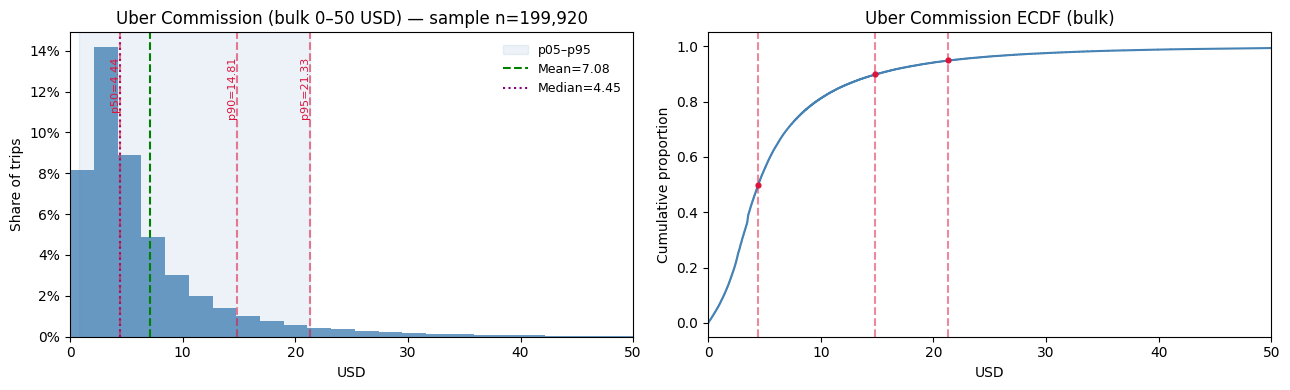

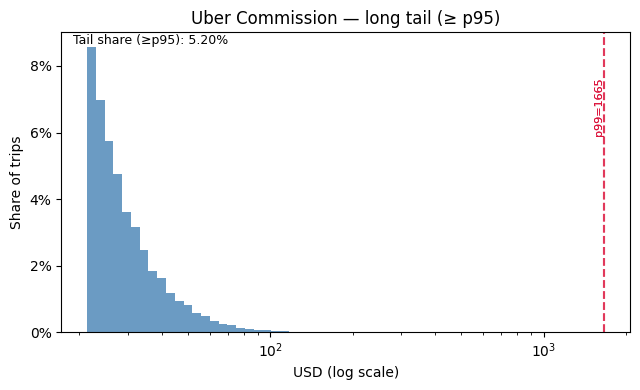

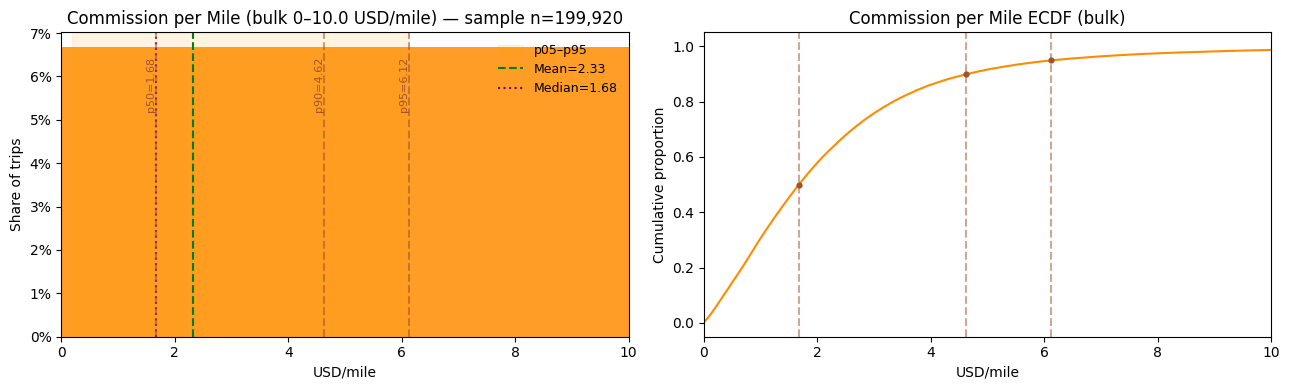

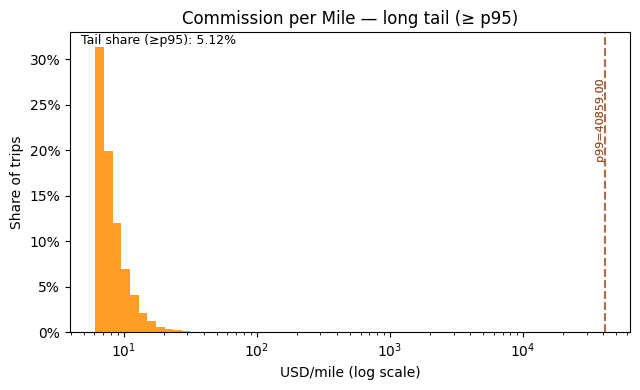

,percentile,uber_commission,y_cpm
0,p05,0.77,0.181342
1,p50,4.44,1.675214
2,p90,14.81,4.622951
3,p95,21.33,6.122807
4,p99,1665.30,40859.000000
5,p99.5,1665.30,40859.000000


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pyspark.sql import functions as F

# ---------------------------
# 1) Percentiles from FULL Spark DF
# ---------------------------
ps = [0.05, 0.50, 0.90, 0.95, 0.99, 0.995]
q_comm = df.stat.approxQuantile("uber_commission", ps, 0.01)
q_rpm  = df.stat.approxQuantile("y_cpm",           ps, 0.01)
p2q = lambda arr: dict(zip(ps, arr))
q_comm_d, q_rpm_d = p2q(q_comm), p2q(q_rpm)

# ---------------------------
# 2) Pandas sample for plotting/ECDF
# ---------------------------
pdf = pdf_sample[["uber_commission", "y_cpm"]].dropna().copy()
n_sample = len(pdf)

# Helpers
def to_percent(y, _pos):
    return f"{y*100:.0f}%"

def ecdf(arr):
    x = np.sort(arr)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

def annotate_quantiles(ax, qdict, color, which=(0.5, 0.9, 0.99)):
    for p in which:
        v = qdict[p]
        ax.axvline(v, color=color, linestyle="--", alpha=0.55)
        ax.text(v, ax.get_ylim()[1]*0.92, f"p{int(p*100)}={v:.2f}" if v<1000 else f"p{int(p*100)}={v:.0f}",
                rotation=90, va="top", ha="right", fontsize=8, color=color)

def add_mean_median(ax, series, color_mean="green", color_med="purple"):
    mean_v, med_v = series.mean(), series.median()
    ax.axvline(mean_v, color=color_mean, linestyle="--", label=f"Mean={mean_v:.2f}")
    ax.axvline(med_v,  color=color_med,  linestyle=":",  label=f"Median={med_v:.2f}")
    ax.legend(frameon=False, fontsize=9)

# ---------------------------
# 3) Commission plots (bulk + tail)
# ---------------------------
# BULK view (0..p95)
bulk_max_comm = max(50, q_comm_d[0.95])   # ensure at least 0–50 is visible
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (density in %), shaded p05–p95 band
axes[0].hist(pdf["uber_commission"], bins=160, density=True, color="steelblue", alpha=0.8)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))
axes[0].yaxis.set_major_formatter(FuncFormatter(to_percent))
axes[0].set_xlim(0, bulk_max_comm)
axes[0].axvspan(q_comm_d[0.05], q_comm_d[0.95], color="steelblue", alpha=0.10, label="p05–p95")
add_mean_median(axes[0], pdf["uber_commission"])
annotate_quantiles(axes[0], q_comm_d, "crimson", which=(0.5, 0.9, 0.95))
axes[0].set_title(f"Uber Commission (bulk 0–{bulk_max_comm:.0f} USD) — sample n={n_sample:,}")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Share of trips")

# ECDF (same bulk range)
x, y = ecdf(pdf["uber_commission"].values)
axes[1].plot(x, y, color="steelblue")
axes[1].set_xlim(0, bulk_max_comm)
axes[1].set_xlabel("USD")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_title("Uber Commission ECDF (bulk)")
for p in (0.5, 0.9, 0.95):
    v = q_comm_d[p]
    axes[1].axvline(v, color="crimson", linestyle="--", alpha=0.5)
    axes[1].scatter([v], [p], color="crimson", s=12, zorder=5)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dist_commission_bulk.png", dpi=250, bbox_inches="tight")
plt.show()

# TAIL view (>= p95, log x)
tail_comm = pdf.loc[pdf["uber_commission"] >= q_comm_d[0.95], "uber_commission"].values
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
if len(tail_comm) > 0:
    bins = np.logspace(np.log10(max(q_comm_d[0.95], 1e-2)),
                       np.log10(max(tail_comm.max(), q_comm_d[0.995])),
                       60)
    ax.hist(tail_comm, bins=bins, density=True, color="steelblue", alpha=0.8)
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
    ax.set_xlabel("USD (log scale)")
    ax.set_ylabel("Share of trips")
    ax.set_title("Uber Commission — long tail (≥ p95)")
    # mark p99 and p99.5
    for p in (0.99, 0.995):
        v = q_comm_d[p]
        ax.axvline(v, color="crimson", linestyle="--", alpha=0.6)
        ax.text(v, ax.get_ylim()[1]*0.85, f"p{int(p*100)}={v:.0f}",
                rotation=90, va="top", ha="right", fontsize=8, color="crimson")
    tail_pct = (len(tail_comm) / n_sample) * 100
    ax.text(0.02, 0.96, f"Tail share (≥p95): {tail_pct:.2f}%", transform=ax.transAxes, fontsize=9)
else:
    ax.text(0.5, 0.5, "No values ≥ p95 in sample", ha="center", va="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dist_commission_tail.png", dpi=250, bbox_inches="tight")
plt.show()

# ---------------------------
# 4) Commission-per-mile plots (bulk + tail)
# ---------------------------
bulk_max_rpm = max(10, q_rpm_d[0.95])  # show at least 0–10 USD/mile
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(pdf["y_cpm"], bins=160, density=True, color="darkorange", alpha=0.85)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))
axes[0].yaxis.set_major_formatter(FuncFormatter(to_percent))
axes[0].set_xlim(0, bulk_max_rpm)
axes[0].axvspan(q_rpm_d[0.05], q_rpm_d[0.95], color="orange", alpha=0.12, label="p05–p95")
add_mean_median(axes[0], pdf["y_cpm"])
annotate_quantiles(axes[0], q_rpm_d, "sienna", which=(0.5, 0.9, 0.95))
axes[0].set_title(f"Commission per Mile (bulk 0–{bulk_max_rpm:.1f} USD/mile) — sample n={n_sample:,}")
axes[0].set_xlabel("USD/mile")
axes[0].set_ylabel("Share of trips")

x2, y2 = ecdf(pdf["y_cpm"].values)
axes[1].plot(x2, y2, color="darkorange")
axes[1].set_xlim(0, bulk_max_rpm)
axes[1].set_xlabel("USD/mile")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_title("Commission per Mile ECDF (bulk)")
for p in (0.5, 0.9, 0.95):
    v = q_rpm_d[p]
    axes[1].axvline(v, color="sienna", linestyle="--", alpha=0.5)
    axes[1].scatter([v], [p], color="sienna", s=12, zorder=5)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dist_cpm_bulk.png", dpi=250, bbox_inches="tight")
plt.show()

tail_rpm = pdf.loc[pdf["y_cpm"] >= q_rpm_d[0.95], "y_cpm"].values
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4))
if len(tail_rpm) > 0:
    bins = np.logspace(np.log10(max(q_rpm_d[0.95], 1e-3)),
                       np.log10(max(tail_rpm.max(), q_rpm_d[0.995])),
                       60)
    ax.hist(tail_rpm, bins=bins, density=True, color="darkorange", alpha=0.85)
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
    ax.set_xlabel("USD/mile (log scale)")
    ax.set_ylabel("Share of trips")
    ax.set_title("Commission per Mile — long tail (≥ p95)")
    for p in (0.99, 0.995):
        v = q_rpm_d[p]
        ax.axvline(v, color="sienna", linestyle="--", alpha=0.6)
        ax.text(v, ax.get_ylim()[1]*0.85, f"p{int(p*100)}={v:.2f}",
                rotation=90, va="top", ha="right", fontsize=8, color="sienna")
    tail_pct = (len(tail_rpm) / n_sample) * 100
    ax.text(0.02, 0.96, f"Tail share (≥p95): {tail_pct:.2f}%", transform=ax.transAxes, fontsize=9)
else:
    ax.text(0.5, 0.5, "No values ≥ p95 in sample", ha="center", va="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/dist_cpm_tail.png", dpi=250, bbox_inches="tight")
plt.show()

# ---------------------------
# 5) Optional: compact summary table for the report
# ---------------------------
summary = pd.DataFrame({
    "percentile": ["p05", "p50", "p90", "p95", "p99", "p99.5"],
    "uber_commission": [q_comm_d[p] for p in ps],
    "y_cpm":            [q_rpm_d[p]  for p in ps]
})
summary


### 2) Coverage and missingness
We verify external feature availability via the `coverage` reports and compute null rates for key predictors in the unioned dataset. This informs imputation policy and the reliability of joins.


In [10]:
# Coverage from reports (optional)
try:
    cov = (spark.read.option("recursiveFileLookup","true")
                 .option("pathGlobFilter","*.parquet")
                 .parquet("./lake/reports/coverage"))
    cov_ordered = cov.orderBy("year","month","group","column")
    cov_ordered.show(20, truncate=False)
except Exception as e:
    print("Coverage parquet not available:", e)

# Null rates for key external features in combined df
key_cols = [c for c in [
    "PU_Borough","DO_Borough","PU_Zone","DO_Zone","trip_cbd_type",
    "pickup_hour","is_holiday","day_of_week","is_weekend","rush_hour_label",
    "temp_avg_calculated","precipitation_mm","is_snow","wind_speed_kmh","fog_flag"
] if c in df.columns]

null_rates = []
for c in key_cols:
    nn = df.filter(F.col(c).isNotNull()).count()
    tot = df.count()
    null_rates.append({"column": c, "non_null": nn, "total": tot, "null_pct": round(100*(1 - nn/max(tot,1)), 2)})

import pandas as pd
pd.DataFrame(null_rates).sort_values("null_pct", ascending=False)


+----+-----+--------+-------------------+--------+--------+------------+
|year|month|group   |column             |non_null|total   |coverage_pct|
+----+-----+--------+-------------------+--------+--------+------------+
|2023|1    |spatial |DO_Borough         |12109197|12109197|100.0       |
|2023|1    |spatial |DO_Zone            |12109197|12109197|100.0       |
|2023|1    |spatial |PU_Borough         |12109197|12109197|100.0       |
|2023|1    |spatial |PU_Zone            |12109197|12109197|100.0       |
|2023|1    |spatial |trip_cbd_type      |12109197|12109197|100.0       |
|2023|1    |temporal|is_holiday         |12109197|12109197|100.0       |
|2023|1    |temporal|is_weekend         |12109197|12109197|100.0       |
|2023|1    |temporal|pickup_hour        |12109197|12109197|100.0       |
|2023|1    |temporal|rush_hour_label    |12109197|12109197|100.0       |
|2023|1    |weather |fog_flag           |12109197|12109197|100.0       |
|2023|1    |weather |is_snow            |12109197|1

,column,non_null,total,null_pct
0,PU_Borough,290096301,290096301,0.0
1,DO_Borough,290096301,290096301,0.0
2,PU_Zone,290096301,290096301,0.0
3,DO_Zone,290096301,290096301,0.0
4,trip_cbd_type,290096301,290096301,0.0
5,pickup_hour,290096301,290096301,0.0
6,is_holiday,290096301,290096301,0.0
7,is_weekend,290096301,290096301,0.0
8,rush_hour_label,290096301,290096301,0.0
9,temp_avg_calculated,290096301,290096301,0.0


In [4]:
df.select("PU_Zone").distinct().count()


261

### 3) Temporal patterns
We examine hourly and monthly profitability, splitting by weekday/weekend and annotating rush-hour bands. This supports dispatch timing decisions.


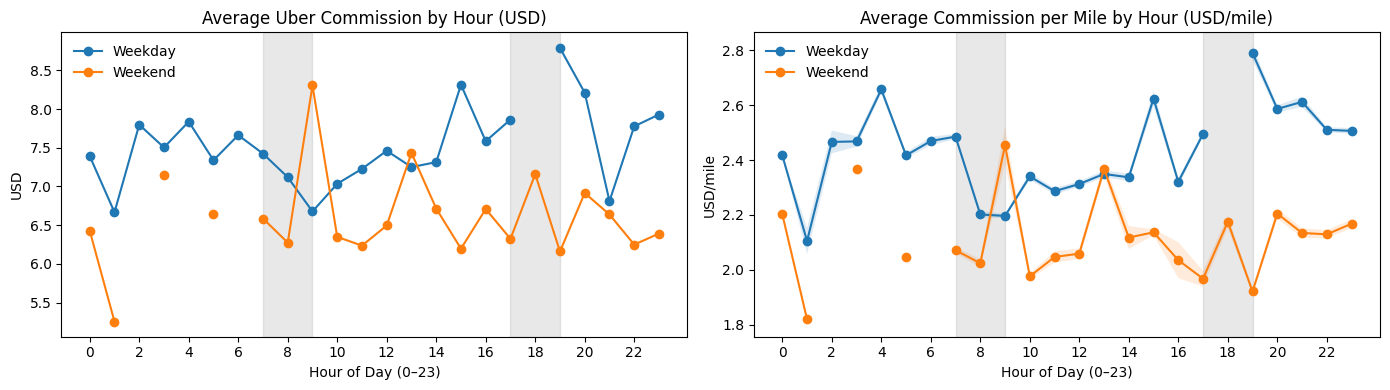

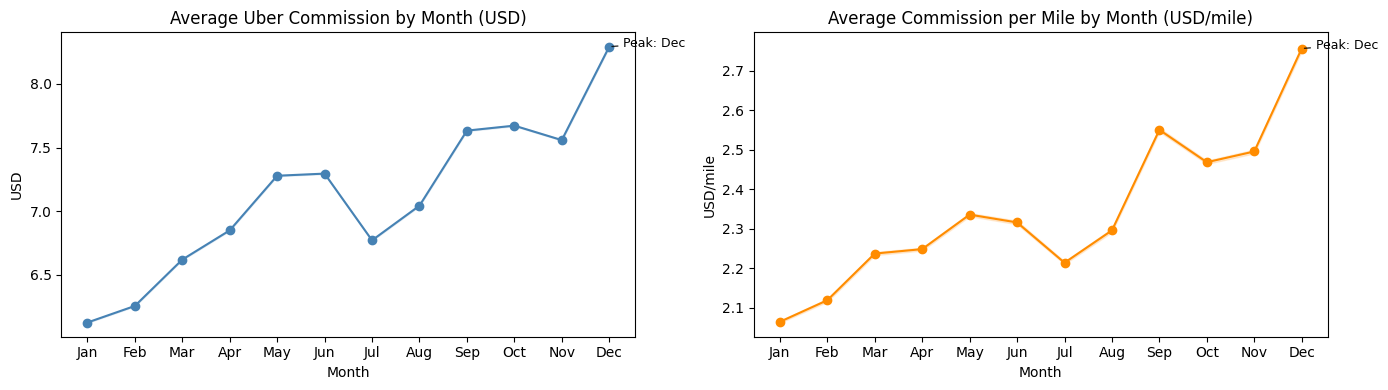

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar
from pyspark.sql import functions as F

# ----------------------------
# Helper: aggregate with CI
# ----------------------------
def agg_with_ci(sdf, group_cols, value_col):
    agg = (sdf.groupBy(*group_cols)
           .agg(F.mean(value_col).alias("mean"),
                F.stddev_samp(value_col).alias("sd"),
                F.count(F.lit(1)).alias("n")))
    agg = agg.withColumn("se", F.col("sd")/F.sqrt(F.col("n")))
    agg = agg.withColumn("lo", F.col("mean") - F.lit(1.96)*F.col("se"))
    agg = agg.withColumn("hi", F.col("mean") + F.lit(1.96)*F.col("se"))
    return agg.orderBy(*group_cols)

# Detect optional columns
hour_col = "pickup_hour" if "pickup_hour" in df.columns else None
month_col = "pickup_month" if "pickup_month" in df.columns else None
weekend_col = "is_weekend" if "is_weekend" in df.columns else None

# ----------------------------
# Hourly profiles (commission & y_cpm)
# ----------------------------
if hour_col:
    # Commission
    gcols_comm = [hour_col] + ([weekend_col] if weekend_col else [])
    hourly_comm = agg_with_ci(df, gcols_comm, "uber_commission").toPandas()

    # Per-mile
    gcols_rpm = [hour_col] + ([weekend_col] if weekend_col else [])
    hourly_rpm  = agg_with_ci(df, gcols_rpm, "y_cpm").toPandas()

    # Off-peak baseline (02–05) for % change annotations
    def pct_change_vs_offpeak(pdf, value="mean"):
        offpeak = pdf[(pdf[hour_col] >= 2) & (pdf[hour_col] <= 5)][value].mean()
        pdf["pct_vs_offpeak"] = (pdf[value]/offpeak - 1.0) * 100.0
        return pdf, offpeak

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

    def draw_hour_panel(axx, pdf, title, ylab, color, shade_rush=True):
        if weekend_col and weekend_col in pdf.columns:
            # Pivot to weekday/weekend lines
            pv = pdf.pivot(index=hour_col, columns=weekend_col, values=["mean", "lo", "hi"]).sort_index()
            # weekend_col: 0/1 or False/True; map to labels
            lab_map = {0: "Weekday", 1: "Weekend", False: "Weekday", True: "Weekend"}
            for k in pv["mean"].columns:
                line_lab = lab_map.get(k, str(k))
                axx.plot(pv.index, pv["mean"][k], marker="o", label=line_lab)
                axx.fill_between(pv.index, pv["lo"][k], pv["hi"][k], alpha=0.15)
        else:
            pdf = pdf.sort_values(hour_col)
            axx.plot(pdf[hour_col], pdf["mean"], marker="o", color=color)
            axx.fill_between(pdf[hour_col], pdf["lo"], pdf["hi"], alpha=0.15, color=color)

        axx.set_title(title)
        axx.set_xlabel("Hour of Day (0–23)")
        axx.set_ylabel(ylab)
        axx.set_xticks(range(0, 24, 2))
        if shade_rush:
            axx.axvspan(7, 9, color="grey", alpha=0.18)
            axx.axvspan(17, 19, color="grey", alpha=0.18)
        if weekend_col and weekend_col in pdf.columns:
            axx.legend(frameon=False, loc="best")

        # Annotate peak hour (+% vs off-peak)
        if not (weekend_col and weekend_col in pdf.columns):
            pdf, off = pct_change_vs_offpeak(pdf)
            idx = pdf["mean"].idxmax()
            hx, hy, pct = pdf.loc[idx, hour_col], pdf.loc[idx, "mean"], pdf.loc[idx, "pct_vs_offpeak"]
            axx.annotate(f"Peak: {int(hx)}h\n+{pct:.1f}% vs off-peak",
                         xy=(hx, hy), xytext=(hx+0.6, hy),
                         arrowprops=dict(arrowstyle="-", alpha=0.8), fontsize=9)

    draw_hour_panel(ax[0], hourly_comm, "Average Uber Commission by Hour (USD)", "USD", "steelblue")
    draw_hour_panel(ax[1], hourly_rpm,  "Average Commission per Mile by Hour (USD/mile)", "USD/mile", "darkorange")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/temporal_hourly_enhanced.png", dpi=250, bbox_inches="tight")
    plt.show()

# ----------------------------
# Monthly profiles (commission & y_cpm)
# ----------------------------
if month_col:
    monthly_comm = agg_with_ci(df, [month_col], "uber_commission").toPandas().sort_values(month_col)
    monthly_rpm  = agg_with_ci(df, [month_col], "y_cpm").toPandas().sort_values(month_col)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

    def draw_month_panel(axx, pdf, title, ylab, color):
        axx.plot(pdf[month_col], pdf["mean"], marker="o", color=color)
        axx.fill_between(pdf[month_col], pdf["lo"], pdf["hi"], color=color, alpha=0.15)
        axx.set_title(title)
        axx.set_xlabel("Month")
        axx.set_ylabel(ylab)
        axx.set_xticks(range(1, 13))
        axx.set_xticklabels(calendar.month_abbr[1:])
        # annotate peak month
        idx = pdf["mean"].idxmax()
        mx, my = int(pdf.loc[idx, month_col]), pdf.loc[idx, "mean"]
        axx.annotate(f"Peak: {calendar.month_abbr[mx]}",
                     xy=(mx, my), xytext=(mx+0.3, my),
                     arrowprops=dict(arrowstyle="-", alpha=0.8), fontsize=9)

    draw_month_panel(ax[0], monthly_comm, "Average Uber Commission by Month (USD)", "USD", "steelblue")
    draw_month_panel(ax[1], monthly_rpm,  "Average Commission per Mile by Month (USD/mile)", "USD/mile", "darkorange")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/temporal_monthly_enhanced.png", dpi=250, bbox_inches="tight")
    plt.show()


### 4) Spatial patterns: Interactive NYC Commission Maps

We create comprehensive interactive choropleth maps showing commission per mile across all NYC taxi zones. Our implementation includes:

**Key Features:**
- **Full zone coverage**: All 265 NYC taxi zones with ride data visualization
- **Outlier-robust color scaling**: Cap extreme values at 95th percentile for better visual contrast
- **Interactive tooltips**: Click zones to see exact commission values
- **Smart data handling**: Light gray for zones without data, green gradient for active zones
- **Outlier identification**: Orange markers highlight extreme values above 99th percentile

**Technical Implementation:**
- **Folium-based**: Professional interactive maps with zoom/pan capabilities
- **GeoPandas integration**: Joins aggregated Spark data with NYC taxi zone geometries  
- **Percentile-based bins**: Ensures meaningful color distribution across normal value ranges
- **Dual visualization**: Separate maps for pickup and dropoff zone analysis

**Output Files:**
- `pickup_zones_fixed_scale.html` - Interactive pickup zone commission analysis
- `dropoff_zones_fixed_scale.html` - Interactive dropoff zone commission analysis


In [26]:
# Section 4 prerequisites: ensure helpers and geometry exist in any run order
from pyspark.sql import functions as F

# 1) Ensure safe_spark_to_pandas exists
try:
    safe_spark_to_pandas
except NameError:
    def safe_spark_to_pandas(sdf, label: str = "data", sample_frac: float = 1.0, seed: int = 42):
        """
        Safely convert a Spark DataFrame to Pandas, with optional sub-sampling.
        - If sample_frac < 1.0, random-sample rows for speed.
        - If sdf is None or empty, return None.
        """
        if sdf is None:
            return None
        try:
            if sample_frac < 1.0:
                sdf = sdf.sample(withReplacement=False, fraction=sample_frac, seed=seed)
            n = sdf.count()
            if n == 0:
                return None
            pdf = sdf.toPandas()
            return pdf
        except Exception as e:
            print(f"[safe_spark_to_pandas] Failed converting {label}: {e}")
            return None

# 2) Ensure geometry with centroids exists
try:
    gzones_with_centroids
except NameError:
    try:
        import geopandas as gpd
        g = gpd.read_file("lake/landing/lookups/taxi_zones.geojson")
        key = next((c for c in g.columns if c.lower() in ("locationid","location_id")), None)
        if key and key != "LocationID":
            g = g.rename(columns={key: "LocationID"})
        g["LocationID"] = g["LocationID"].astype("int64")
        # centroids in lat/lon for tooltip/markers
        g["centroid"] = g.geometry.centroid.apply(lambda ge: [ge.y, ge.x])
        gzones_with_centroids = g
        print(f"✅ Loaded {len(gzones_with_centroids)} taxi zones with centroids")
    except Exception as e:
        print(f"[setup] Unable to load taxi zones geometry: {e}")

# 3) Ensure key name used for merges
if "loc_col" not in globals():
    loc_col = "LocationID"

# 4) If df is already available, prepare spatial aggregates used in maps
if "df" in globals():
    try:
        agg_pu
    except NameError:
        try:
            agg_pu = (
                df.where(F.col("PULocationID").isNotNull() & F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
                  .groupBy("PULocationID")
                  .agg(F.count("*").alias("pu_n_trips"), F.mean("y_cpm").alias("pu_avg_cpm"))
            )
        except Exception as e:
            print(f"[setup] Failed to build agg_pu: {e}")
    try:
        agg_do
    except NameError:
        try:
            agg_do = (
                df.where(F.col("DOLocationID").isNotNull() & F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
                  .groupBy("DOLocationID")
                  .agg(F.count("*").alias("do_n_trips"), F.mean("y_cpm").alias("do_avg_cpm"))
            )
        except Exception as e:
            print(f"[setup] Failed to build agg_do: {e}")

print("Section 4 setup ready.")


Section 4 setup ready.


In [27]:
from pyspark.sql import functions as F

# Ensure geometry is available
try:
    gzones_with_centroids
except NameError:
    import geopandas as gpd
    g = gpd.read_file("lake/landing/lookups/taxi_zones.geojson")
    # Normalize LocationID if needed
    key = next((c for c in g.columns if c.lower() in ("locationid","location_id")), None)
    if key and key != "LocationID":
        g = g.rename(columns={key: "LocationID"})
    g["LocationID"] = g["LocationID"].astype("int64")
    g["centroid"] = g.geometry.centroid.apply(lambda ge: [ge.y, ge.x])
    gzones_with_centroids = g

# Key column name used in merges
loc_col = "LocationID"

# Spark aggregates: average commission per mile by PU/DO zone
agg_pu = (
    df.where(F.col("PULocationID").isNotNull() & F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
      .groupBy("PULocationID")
      .agg(F.count("*").alias("pu_n_trips"), F.mean("y_cpm").alias("pu_avg_cpm"))
)

agg_do = (
    df.where(F.col("DOLocationID").isNotNull() & F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
      .groupBy("DOLocationID")
      .agg(F.count("*").alias("do_n_trips"), F.mean("y_cpm").alias("do_avg_cpm"))
)

# Convert to pandas and merge with geometry
pu_map_fixed = None
do_map_fixed = None

pu_pdf = safe_spark_to_pandas(agg_pu, "pickup data")
if pu_pdf is not None:
    pu_pdf.rename(columns={"PULocationID": "LocationID"}, inplace=True)
    pu_map_fixed = gzones_with_centroids.merge(pu_pdf, left_on=loc_col, right_on="LocationID", how="left")

do_pdf = safe_spark_to_pandas(agg_do, "dropoff data")
if do_pdf is not None:
    do_pdf.rename(columns={"DOLocationID": "LocationID"}, inplace=True)
    do_map_fixed = gzones_with_centroids.merge(do_pdf, left_on=loc_col, right_on="LocationID", how="left")

print("Ready for mapping:",
      f"PU map: {pu_map_fixed is not None}, DO map: {do_map_fixed is not None}")

✅ Converted pickup data SparkDF → Pandas: 262 rows


✅ Converted dropoff data SparkDF → Pandas: 264 rows
Ready for mapping: PU map: True, DO map: True


In [28]:
# Fixed Color Scale - Remove Outliers for Better Visualization
import folium
print("🔧 Creating FIXED color scale maps (capping outliers)...")

def create_fixed_folium_choropleth(merged_gdf, value_col, title, filename, color_scheme='Greens'):
    """Fixed Folium choropleth with outlier-capped color scaling"""
    
    # Filter valid data
    valid_data = merged_gdf[merged_gdf[value_col].notna() & (merged_gdf[value_col] > 0)]
    
    if len(valid_data) == 0:
        print(f"❌ No valid data for {title}")
        return None
    
    # Calculate percentiles for outlier capping
    p95 = valid_data[value_col].quantile(0.95)
    p99 = valid_data[value_col].quantile(0.99)
    
    print(f"📊 {title}: {len(valid_data)}/{len(merged_gdf)} zones have data")
    print(f"   Raw range: ${valid_data[value_col].min():.2f} - ${valid_data[value_col].max():.2f}")
    print(f"   95th percentile: ${p95:.2f}")
    print(f"   99th percentile: ${p99:.2f}")
    
    # Cap outliers at 95th percentile for color scaling
    display_data = valid_data.copy()
    display_data[value_col + '_capped'] = display_data[value_col].clip(upper=p95)
    
    # Create base map
    m = folium.Map(
        location=[40.73, -73.94],
        tiles="cartodb positron",
        zoom_start=10,
        zoom_control=True,
        width=900,
        height=700
    )
    
    # Add title with outlier info
    title_html = f'''
    <h3 align="center" style="font-size:18px; margin-top:10px; color:#2c3e50;"><b>
    {title}</b></h3>
    <p align="center" style="font-size:12px; color:#7f8c8d; margin-top:5px;">
    {len(valid_data)} of 265 NYC zones have data (color scale capped at 95th percentile: ${p95:.1f})
    </p>'''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Create safe bins using min/max of capped data
    min_val = display_data[value_col + '_capped'].min()
    max_val = display_data[value_col + '_capped'].max()
    
    # Ensure bins cover the full range of capped data
    if min_val == max_val:
        # Handle edge case where all values are the same
        bins = [min_val - 0.1, min_val, max_val + 0.1]
    else:
        # Create percentile-based bins with guaranteed coverage
        percentiles = [0, 20, 40, 60, 80, 100]
        bins = [display_data[value_col + '_capped'].quantile(p/100) for p in percentiles]
        bins = sorted(list(set(bins)))  # Remove duplicates
        # Ensure first bin starts below min and last bin ends above max
        bins[0] = min(bins[0], min_val - 0.01)
        bins[-1] = max(bins[-1], max_val + 0.01)
    
    print(f"   Using bins: {[f'${b:.2f}' for b in bins]}")
    
    # Create choropleth with CAPPED data for color scaling
    c = folium.Choropleth(
        geo_data=merged_gdf,
        name='choropleth',
        data=display_data[[loc_col, value_col + '_capped']],  # Use capped values
        columns=[loc_col, value_col + '_capped'],
        key_on=f'properties.{loc_col}',
        bins=bins,
        fill_color=color_scheme,
        fill_opacity=0.8,
        line_opacity=0.8,
        line_color='black',
        line_weight=1,
        nan_fill_color='#f0f0f0',
        nan_fill_opacity=0.4,
        legend_name=f'Commission per Mile ($) - Capped at ${p95:.1f}'
    )
    c.add_to(m)
    
    # Add tooltips showing ACTUAL values (not capped)
    folium.GeoJson(
        merged_gdf,
        style_function=lambda x: {
            'fillColor': 'transparent',
            'color': 'transparent',
            'weight': 0
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[loc_col, value_col] if value_col in merged_gdf.columns else [loc_col],
            aliases=['Zone ID:', 'Actual Commission/Mile:'] if value_col in merged_gdf.columns else ['Zone ID:'],
            localize=True,
            sticky=False,
            labels=True,
            style="""
                background-color: white;
                border: 2px solid black;
                border-radius: 3px;
                box-shadow: 3px;
            """
        )
    ).add_to(m)
    
    # Mark extreme outliers with special markers
    extreme_outliers = valid_data[valid_data[value_col] > p99]
    for _, row in extreme_outliers.iterrows():
        if hasattr(row, 'centroid') and row['centroid']:
            folium.Marker(
                location=row['centroid'],
                popup=f"OUTLIER: Zone {row[loc_col]}<br>Actual: ${row[value_col]:.2f}/mile<br>(Above 99th percentile: ${p99:.2f})",
                icon=folium.Icon(color='orange', icon='exclamation-triangle')
            ).add_to(m)
    
    # Add improved legend
    legend_html = f'''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 250px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:12px; padding: 10px">
    <p><b>Legend (Fixed Color Scale)</b></p>
    <p>🟢 Green gradient: $0 - ${p95:.1f}/mile</p>
    <p>⚪ Light gray: No ride data</p>
    <p>🟠 Orange markers: Extreme outliers (>${p99:.1f})</p>
    <p>💡 Hover zones for actual values</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Save map
    m.save(filename)
    print(f"✅ Fixed color scale map saved: {filename}")
    return filename

# Create FIXED interactive maps
fixed_plots = []

if agg_pu is not None:
    pu_pdf = safe_spark_to_pandas(agg_pu, "pickup data")
    if pu_pdf is not None:
        pu_pdf.rename(columns={"PULocationID": "LocationID"}, inplace=True)
        pu_map_fixed = gzones_with_centroids.merge(
            pu_pdf, left_on=loc_col, right_on="LocationID", how="left"
        )
        fixed_plots.append(
            create_fixed_folium_choropleth(
                pu_map_fixed, 
                "pu_avg_cpm",
                "NYC Pickup Zones Commission per Mile",
                f"{FIG_DIR}/pickup_zones_fixed_scale.html",
                'Greens'
            )
        )

if agg_do is not None:
    do_pdf = safe_spark_to_pandas(agg_do, "dropoff data")
    if do_pdf is not None:
        do_pdf.rename(columns={"DOLocationID": "LocationID"}, inplace=True)
        do_map_fixed = gzones_with_centroids.merge(
            do_pdf, left_on=loc_col, right_on="LocationID", how="left"
        )
        fixed_plots.append(
            create_fixed_folium_choropleth(
                do_map_fixed, 
                "do_avg_cpm",
                "NYC Dropoff Zones Commission per Mile",
                f"{FIG_DIR}/dropoff_zones_fixed_scale.html",
                'BuGn'
            )
        )

print(f"\n🎯 Fixed color scale maps created: {fixed_plots}")



🔧 Creating FIXED color scale maps (capping outliers)...


✅ Converted pickup data SparkDF → Pandas: 262 rows
📊 NYC Pickup Zones Commission per Mile: 259/260 zones have data
   Raw range: $0.99 - $376.58
   95th percentile: $3.51
   99th percentile: $3.99
   Using bins: ['$0.98', '$1.60', '$1.76', '$1.89', '$2.37', '$3.52']
✅ Fixed color scale map saved: ./lake/reports/figures/pickup_zones_fixed_scale.html
✅ Converted dropoff data SparkDF → Pandas: 264 rows
📊 NYC Dropoff Zones Commission per Mile: 259/260 zones have data
   Raw range: $0.92 - $4.39
   95th percentile: $3.64
   99th percentile: $4.22
   Using bins: ['$0.91', '$1.65', '$1.80', '$1.92', '$2.37', '$3.65']
✅ Fixed color scale map saved: ./lake/reports/figures/dropoff_zones_fixed_scale.html

🎯 Fixed color scale maps created: ['./lake/reports/figures/pickup_zones_fixed_scale.html', './lake/reports/figures/dropoff_zones_fixed_scale.html']


### View the interactive heat maps on localhost
NOTE: change the directory when needed
- **Outputs**
  - `/home/samho/project-1-individual-samhouhaoyang/lake/reports/figures/pickup_zones_fixed_scale.html`
  - `/home/samho/project-1-individual-samhouhaoyang/lake/reports/figures/dropoff_zones_fixed_scale.html`

- **Method 1 — Open directly (fastest)**
```bash
xdg-open /home/samho/project-1-individual-samhouhaoyang/lake/reports/figures/pickup_zones_fixed_scale.html
xdg-open /home/samho/project-1-individual-samhouhaoyang/lake/reports/figures/dropoff_zones_fixed_scale.html
```

- **Method 2 — Serve via localhost (recommended on WSL2)**
```bash
cd /home/samho/project-1-individual-samhouhaoyang
python3 -m http.server 8000
```
  - Then open:
    - `http://127.0.0.1:8000/lake/reports/figures/pickup_zones_fixed_scale.html`
    - `http://127.0.0.1:8000/lake/reports/figures/dropoff_zones_fixed_scale.html`

- **Method 3 — Display inside the notebook**
```python
from IPython.display import IFrame
IFrame("/home/samho/project-1-individual-samhouhaoyang/lake/reports/figures/pickup_zones_fixed_scale.html", width="100%", height=600)
```

- **Notes**
  - Run the mapping cell so the HTML files are created.
  - Keep internet on for base map tiles (CartoDB).
  - On WSL2, Method 2 lets you view in your Windows browser.

Keeping it concise as you prefer [[memory:7680324]].

The TLC lookup defines 265 taxi zones. Two of these (264 ‘Unknown’ and 265 ‘Outside NYC’) are non-spatial placeholders. In our GeoJSON, three additional zones (57 Corona, 104 and 105 Governor’s/Ellis/Liberty Island) were missing, leaving 260 polygons for mapping. We retain these IDs in tabular summaries but display only zones with valid geometry.

### 5) Ride-sharing effects
We compare responses between shared vs non-shared trips and stratify by distance bands to mitigate confounding by trip length.


In [31]:
# Section 5: Ride-sharing effects (Memory Optimized)
import numpy as np

print("📊 Analyzing ride-sharing effects...")

# Check for required columns
if all(col in df.columns for col in ["shared_match_flag", "trip_miles", "y_cpm"]):
    print("✅ Required columns found. Using sample to avoid memory issues...")
    
    # Use a smaller sample to avoid OutOfMemoryError
    df_sample = df.sample(False, 0.01, seed=42)  # 5% sample
    sample_size = df_sample.count()
    print(f"📦 Sample size: {sample_size:,} records")
    
    # Create distance bands
    labels = ["0-2mi", "2-5mi", "5-10mi", "10-20mi", "20+mi"]
    
    df_binned = df_sample.withColumn("dist_band",
                        F.when(F.col("trip_miles") <= 2, labels[0])
                         .when(F.col("trip_miles") <= 5, labels[1])
                         .when(F.col("trip_miles") <= 10, labels[2])
                         .when(F.col("trip_miles") <= 20, labels[3])
                         .otherwise(labels[4]))
    
    # Safer aggregation
    try:
        cmp = (df_binned.groupBy("dist_band", "shared_match_flag")
                 .agg(F.mean("uber_commission").alias("avg_commission"),
                      F.mean("y_cpm").alias("avg_cpm"),
                      F.count("*").alias("trips"))
                 .orderBy("dist_band", "shared_match_flag"))
        
        cmp_result = cmp.toPandas()
        print("📋 Ride-sharing effects by distance band:")
        display(cmp_result)
        
        # Quick insights
        if len(cmp_result) > 0:
            total_trips = cmp_result['trips'].sum()
            shared_trips = cmp_result[cmp_result['shared_match_flag'] == True]['trips'].sum()
            share_rate = shared_trips / total_trips if total_trips > 0 else 0
            print(f"💡 Overall ride-sharing rate in sample: {share_rate:.1%}")
            
    except Exception as e:
        print(f"❌ Error: {e}")
        print("💡 Data too large for analysis - consider smaller sample")
        
else:
    missing_cols = [col for col in ["shared_match_flag", "trip_miles", "y_cpm"] if col not in df.columns]
    print(f"⚠️ Skipped: Missing columns {missing_cols}")
    print("💡 This dataset may not include ride-sharing information")

📊 Analyzing ride-sharing effects...
✅ Required columns found. Using sample to avoid memory issues...


📦 Sample size: 3,021,645 records


📋 Ride-sharing effects by distance band:


,dist_band,shared_match_flag,avg_commission,avg_cpm,trips
0,0-2mi,N,4.081328,3.715110,1089068
1,0-2mi,Y,4.700242,5.056973,4679
2,10-20mi,N,13.969203,1.002254,299417
3,10-20mi,Y,7.150623,0.563947,4448
4,2-5mi,N,5.995254,1.954293,1003812
5,2-5mi,Y,5.186542,1.597631,15022
6,20+mi,N,30.891326,1.039218,75471
7,20+mi,Y,9.673162,0.426870,234
8,5-10mi,N,8.353708,1.191452,517881
9,5-10mi,Y,6.032181,0.878878,11613


💡 Overall ride-sharing rate in sample: 0.0%


In [33]:
from pyspark.sql import functions as F

req = {"shared_match_flag","trip_miles","uber_commission","y_cpm"}
if req <= set(df.columns):
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled","false")
    labels = ["0-2","2-5","5-10","10-20","20+"]

    def compute(pdf):
        b = (pdf.withColumn("dist_band",
             F.when(F.col("trip_miles")<=2,labels[0])
              .when(F.col("trip_miles")<=5,labels[1])
              .when(F.col("trip_miles")<=10,labels[2])
              .when(F.col("trip_miles")<=20,labels[3])
              .otherwise(labels[4])))
        return (b.groupBy("dist_band","shared_match_flag")
                 .agg(F.avg("uber_commission").alias("avg_comm"),
                      F.avg("y_cpm").alias("avg_rpm"),
                      F.count("*").alias("trips"))
                 .orderBy("dist_band","shared_match_flag"))

    base = df.select(*req)
    try:
        cmp_pdf = compute(base).toPandas()
    except Exception:
        cmp_pdf = compute(base.sample(False, 0.05, 42)).toPandas()  # 5% fallback


In [35]:
from IPython.display import display
display(cmp_pdf)

,dist_band,shared_match_flag,avg_comm,avg_rpm,trips
0,0-2,N,4.076499,3.724331,109066817
1,0-2,Y,4.665638,5.191610,469436
2,10-20,N,13.930322,1.000631,29971806
3,10-20,Y,7.147298,0.564598,441737
4,2-5,N,5.998213,1.955793,100221362
5,2-5,Y,5.199411,1.600816,1472696
6,20+,N,31.037362,1.043666,7534188
7,20+,Y,9.279264,0.408384,25664
8,5-10,N,8.364954,1.192802,51917867
9,5-10,Y,6.031621,0.880257,1162743


/tmp/ipykernel_4137408/3905098280.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x="dist_band", y="avg_cpm", hue="Shared", ci=None)


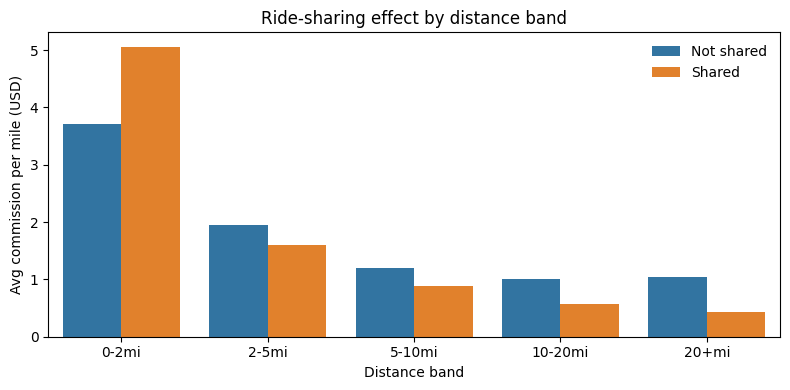

In [36]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# Use existing aggregate from Section 5, whichever exists
try:
    plot_df = cmp_result.copy()  # columns: dist_band, shared_match_flag, avg_commission, avg_cpm, trips
except NameError:
    plot_df = cmp_pdf.rename(columns={"avg_comm":"avg_commission","avg_rpm":"avg_cpm"}).copy()

# Tidy labels
plot_df["Shared"] = plot_df["shared_match_flag"].map({True:"Shared", "Y":"Shared", "Yes":"Shared",
                                                      False:"Not shared", "N":"Not shared", "No":"Not shared"}).fillna("Not shared")
band_order = [b for b in ["0-2mi","2-5mi","5-10mi","10-20mi","20+mi","0-2","2-5","5-10","10-20","20+"] if b in plot_df["dist_band"].unique()]
plot_df["dist_band"] = pd.Categorical(plot_df["dist_band"], categories=band_order, ordered=True)

# Plot avg_cpm
plt.figure(figsize=(8,4))
sns.barplot(data=plot_df, x="dist_band", y="avg_cpm", hue="Shared", ci=None)
plt.xlabel("Distance band")
plt.ylabel("Avg commission per mile (USD)")
plt.title("Ride-sharing effect by distance band")
plt.legend(title="", frameon=False)
plt.tight_layout(); plt.show()

/tmp/ipykernel_4137408/1747865993.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x="dist_band", y="trips", hue="Shared", ci=None)


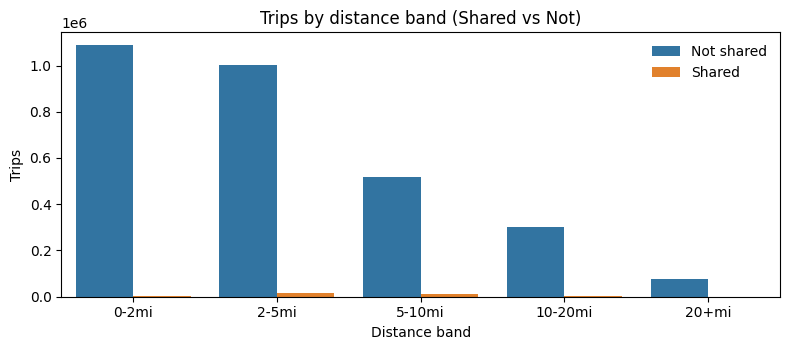

In [37]:
plt.figure(figsize=(8,3.6))
sns.barplot(data=plot_df, x="dist_band", y="trips", hue="Shared", ci=None)
plt.xlabel("Distance band"); plt.ylabel("Trips")
plt.title("Trips by distance band (Shared vs Not)")
plt.legend(title="", frameon=False)
plt.tight_layout(); plt.show()

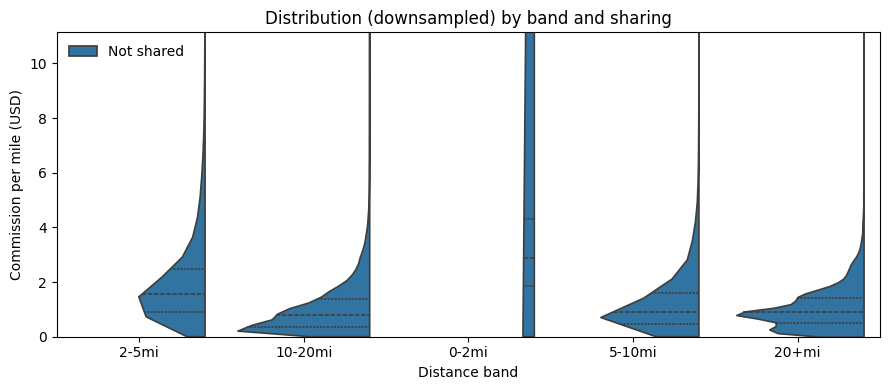

In [38]:
# Small sample per band/shared to visualize distribution
from pyspark.sql import functions as F
labels = ["0-2mi","2-5mi","5-10mi","10-20mi","20+mi"]
df_s = (df.sample(False, 0.005, seed=42)
          .withColumn("dist_band",
              F.when(F.col("trip_miles")<=2,labels[0])
               .when(F.col("trip_miles")<=5,labels[1])
               .when(F.col("trip_miles")<=10,labels[2])
               .when(F.col("trip_miles")<=20,labels[3])
               .otherwise(labels[4])))
pdf_s = df_s.select("y_cpm","shared_match_flag","dist_band").dropna().toPandas()
pdf_s["Shared"] = pdf_s["shared_match_flag"].map({True:"Shared",False:"Not shared"}).fillna("Not shared")

plt.figure(figsize=(9,4))
sns.violinplot(data=pdf_s, x="dist_band", y="y_cpm", hue="Shared", split=True, cut=0, inner="quart")
plt.ylim(0, pdf_s["y_cpm"].quantile(0.99))  # trim extreme tail
plt.xlabel("Distance band"); plt.ylabel("Commission per mile (USD)")
plt.title("Distribution (downsampled) by band and sharing")
plt.legend(title="", frameon=False)
plt.tight_layout(); plt.show()

### 6) Weather effects
We assess sensitivity to temperature, precipitation, snow, wind, and fog using binned summaries and small multiples.


In [34]:
# Temperature bins (5°C)
if "temp_avg_calculated" in df.columns:
    temp_binned = (df.withColumn("temp_bin", (F.floor(F.col("temp_avg_calculated")/5)*5).cast("int"))
                     .groupBy("temp_bin")
                     .agg(F.mean("uber_commission").alias("avg_comm"),
                          F.mean("uber_revenue_per_mile").alias("avg_rpm"),
                          F.count(F.lit(1)).alias("trips"))
                     .orderBy("temp_bin"))
    temp_binned.toPandas()

# Precipitation bins
if "precipitation_mm" in df.columns:
    pr_bins = [0, 2, 5, 10, 25, 1000]
    pr_labels = ["0","0-2","2-5","5-10","10+"]
    pr_binned = (df.withColumn("pr_bin",
                    F.when(F.col("precipitation_mm") <= 0, pr_labels[0])
                     .when(F.col("precipitation_mm") <= 2, pr_labels[1])
                     .when(F.col("precipitation_mm") <= 5, pr_labels[2])
                     .when(F.col("precipitation_mm") <= 10, pr_labels[3])
                     .otherwise(pr_labels[4]))
                  .groupBy("pr_bin")
                  .agg(F.mean("uber_commission").alias("avg_comm"),
                       F.mean("uber_revenue_per_mile").alias("avg_rpm"),
                       F.count(F.lit(1)).alias("trips"))
                  .orderBy("pr_bin"))
    pr_binned.toPandas()

# Binary flags
for flag in ["is_hot","is_freezing","is_snow","fog_flag"]:
    if flag in df.columns:
        out = (df.groupBy(flag)
                 .agg(F.mean("uber_commission").alias("avg_comm"),
                      F.mean("y_cpm").alias("avg_rpm"),
                      F.count(F.lit(1)).alias("trips"))
                 .orderBy(flag))
        print(flag)
        display(out.toPandas())


is_hot


,is_hot,avg_comm,avg_rpm,trips
0,0,7.131771,2.348973,253309302
1,1,7.046870,2.308444,48975014


is_freezing


,is_freezing,avg_comm,avg_rpm,trips
0,0,7.153568,2.342044,264296559
1,1,6.870668,2.344931,37987757


is_snow


,is_snow,avg_comm,avg_rpm,trips
0,0,7.131127,2.342519,296347904
1,1,6.463528,2.336820,5936412


fog_flag


,fog_flag,avg_comm,avg_rpm,trips
0,0,7.157091,2.322834,182744872
1,1,7.058281,2.372329,119539444


/tmp/ipykernel_4137408/667615928.py:57: FutureWarning:                          

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=precip_pdf, x="precip_bin", y="avg_cpm", hue="is_snow_lbl", ax=axes[1], order=order, ci=None)
/tmp/ipykernel_4137408/667615928.py:66: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=wind_pdf, x="wind_bin", y="avg_cpm", ax=axes[2], order=order_w, ci=None, color="#6aaed6")


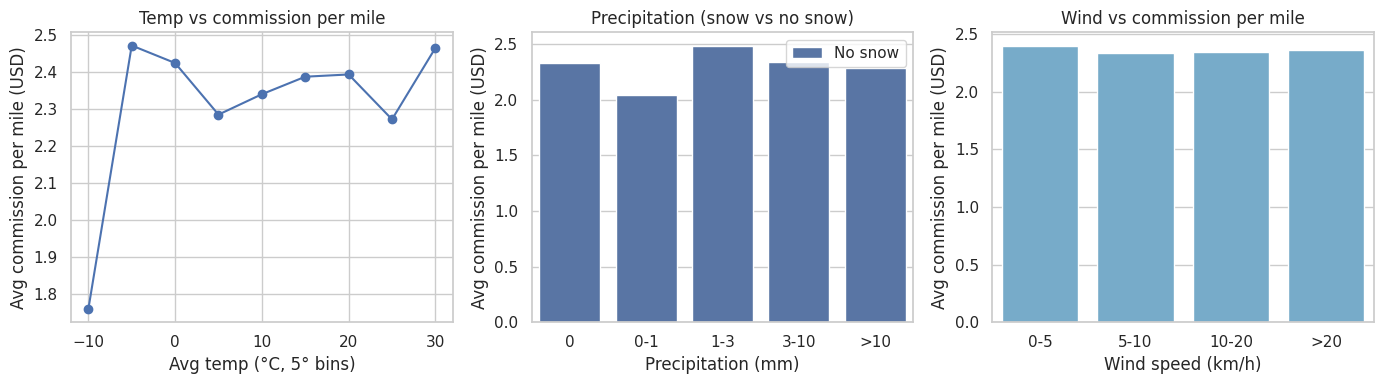

In [39]:
# Weather visuals: temp, precipitation, wind vs avg commission per mile
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pyspark.sql import functions as F

need = {"y_cpm","temp_avg_calculated","precipitation_mm","wind_speed_kmh","is_snow"}
if not need <= set(df.columns):
    print("Missing cols:", sorted(list(need - set(df.columns))))
else:
    base = (df
        .where(F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
        .select("y_cpm","temp_avg_calculated","precipitation_mm","wind_speed_kmh","is_snow"))

    # Binning
    binned = (base
        .withColumn("temp_bin", F.round(F.col("temp_avg_calculated")/5.0)*5)  # 5° bins
        .withColumn("precip_bin",
            F.when(F.col("precipitation_mm")<=0, "0")
             .when(F.col("precipitation_mm")<=1, "0-1")
             .when(F.col("precipitation_mm")<=3, "1-3")
             .when(F.col("precipitation_mm")<=10,"3-10")
             .otherwise(">10"))
        .withColumn("wind_bin",
            F.when(F.col("wind_speed_kmh")<=5, "0-5")
             .when(F.col("wind_speed_kmh")<=10,"5-10")
             .when(F.col("wind_speed_kmh")<=20,"10-20")
             .otherwise(">20"))
    )

    # Aggregates
    temp_pdf = (binned.groupBy("temp_bin")
        .agg(F.mean("y_cpm").alias("avg_cpm"), F.count("*").alias("trips"))
        .orderBy("temp_bin")).toPandas()

    precip_pdf = (binned.groupBy("precip_bin","is_snow")
        .agg(F.mean("y_cpm").alias("avg_cpm"), F.count("*").alias("trips"))
        .orderBy("precip_bin","is_snow")).toPandas()

    wind_pdf = (binned.groupBy("wind_bin")
        .agg(F.mean("y_cpm").alias("avg_cpm"), F.count("*").alias("trips"))
        .orderBy("wind_bin")).toPandas()

    # Plot
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(14,4))

    # Temp (line)
    if len(temp_pdf):
        axes[0].plot(temp_pdf["temp_bin"], temp_pdf["avg_cpm"], marker="o")
        axes[0].set_xlabel("Avg temp (°C, 5° bins)")
        axes[0].set_ylabel("Avg commission per mile (USD)")
        axes[0].set_title("Temp vs commission per mile")

    # Precip (bar, hue snow)
    if len(precip_pdf):
        precip_pdf["is_snow_lbl"] = precip_pdf["is_snow"].map({True:"Snow", False:"No snow"}).fillna("No snow")
        order = [b for b in ["0","0-1","1-3","3-10",">10"] if b in precip_pdf["precip_bin"].unique()]
        sns.barplot(data=precip_pdf, x="precip_bin", y="avg_cpm", hue="is_snow_lbl", ax=axes[1], order=order, ci=None)
        axes[1].set_xlabel("Precipitation (mm)")
        axes[1].set_ylabel("Avg commission per mile (USD)")
        axes[1].set_title("Precipitation (snow vs no snow)")
        axes[1].legend(title="")

    # Wind (bar)
    if len(wind_pdf):
        order_w = [b for b in ["0-5","5-10","10-20",">20"] if b in wind_pdf["wind_bin"].unique()]
        sns.barplot(data=wind_pdf, x="wind_bin", y="avg_cpm", ax=axes[2], order=order_w, ci=None, color="#6aaed6")
        axes[2].set_xlabel("Wind speed (km/h)")
        axes[2].set_ylabel("Avg commission per mile (USD)")
        axes[2].set_title("Wind vs commission per mile")

    plt.tight_layout()
    plt.show()

### 7) Interactions
We visualize hour × CBD-type and hour × weather-condition effects on per-mile revenue to surface differential rush-hour impacts.


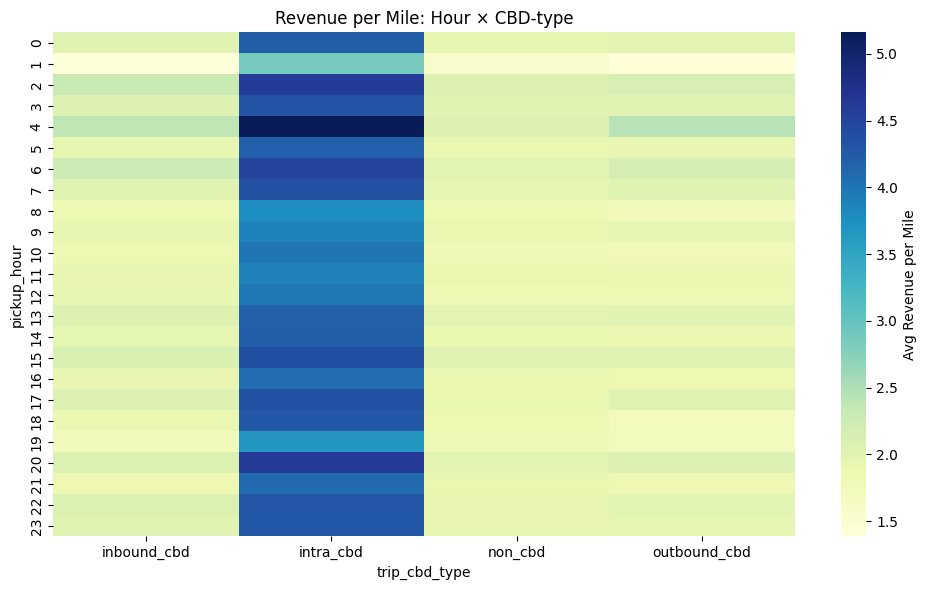

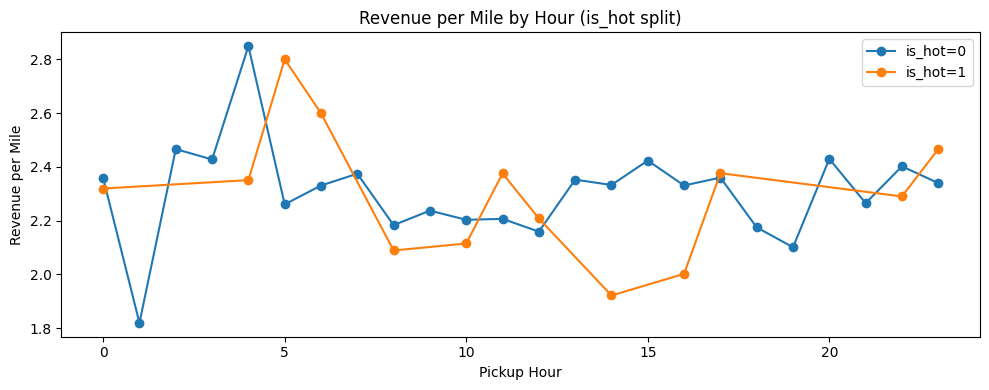

In [58]:
import seaborn as sns

# Hour x CBD-type heatmap
if all(c in df.columns for c in ["pickup_hour","trip_cbd_type","y_cpm"]):
    hm = (df.groupBy("pickup_hour","trip_cbd_type")
             .agg(F.mean("y_cpm").alias("avg_rpm"))
             .orderBy("pickup_hour","trip_cbd_type"))
    hm_pdf = hm.toPandas().pivot(index="pickup_hour", columns="trip_cbd_type", values="avg_rpm")
    plt.figure(figsize=(10,6))
    ax = sns.heatmap(hm_pdf, cmap="YlGnBu", cbar_kws={'label': 'Avg Revenue per Mile'})
    plt.title("Revenue per Mile: Hour × CBD-type")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/interaction_hour_cbd.png", dpi=200, bbox_inches="tight"); plt.show()

# Hour x weather condition
if all(c in df.columns for c in ["pickup_hour","is_hot","y_cpm"]):
    hw = (df.groupBy("pickup_hour","is_hot")
             .agg(F.mean("y_cpm").alias("avg_rpm"))
             .orderBy("pickup_hour","is_hot"))
    hw_pdf = hw.toPandas()
    plt.figure(figsize=(10,4))
    for k, sub in hw_pdf.groupby("is_hot"):
        plt.plot(sub["pickup_hour"], sub["avg_rpm"], marker="o", label=f"is_hot={k}")
    plt.legend()
    plt.title("Revenue per Mile by Hour (is_hot split)")
    plt.xlabel("Pickup Hour")
    plt.ylabel("Revenue per Mile")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/interaction_hour_hot.png", dpi=200, bbox_inches="tight")
    plt.show()


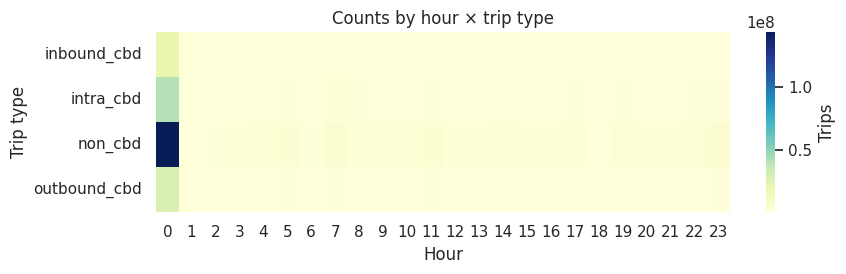

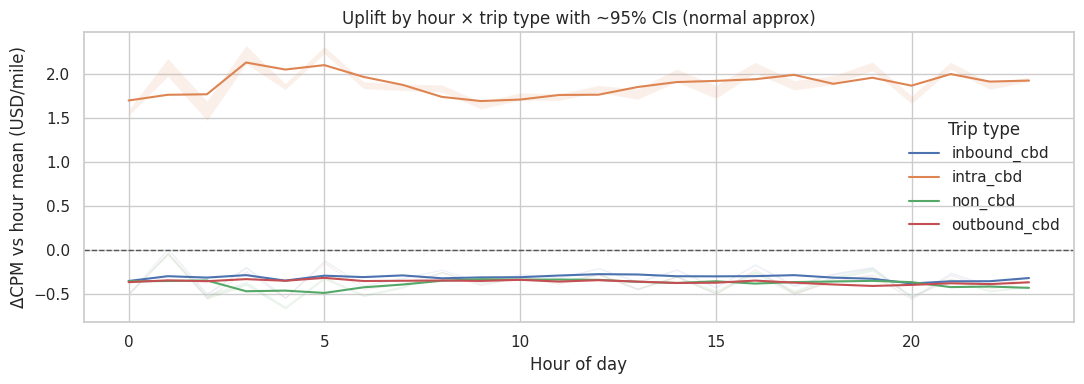

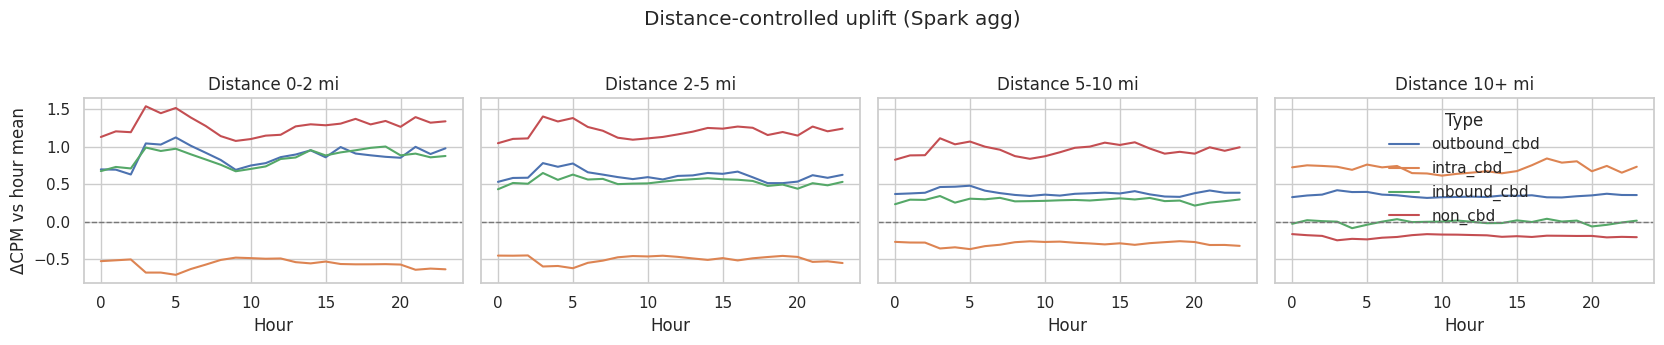

In [5]:
# Section 7 (lite): Spark agg → tiny pandas → plot
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from pyspark.sql import functions as F

sns.set(style="whitegrid")

# Keep only needed cols, filter valid
base = (df.where(F.col("y_cpm").isNotNull() & (F.col("y_cpm") > 0))
          .select("pickup_hour","trip_cbd_type","y_cpm","trip_miles"))

# 1) Counts heatmap (hour × type)
cnt = (base.groupBy("pickup_hour","trip_cbd_type").count()
            .withColumnRenamed("count","n"))
cnt_pdf = cnt.toPandas().pivot(index="trip_cbd_type", columns="pickup_hour", values="n").fillna(0)

plt.figure(figsize=(9, 2.9))
sns.heatmap(cnt_pdf, cmap="YlGnBu", cbar_kws={"label":"Trips"})
plt.title("Counts by hour × trip type")
plt.xlabel("Hour"); plt.ylabel("Trip type")
plt.tight_layout(); plt.show()

# 2) Uplift with normal-approx CIs (no bootstrap)
agg_ht = (base.groupBy("pickup_hour","trip_cbd_type")
               .agg(F.mean("y_cpm").alias("mean_cpm"),
                    F.stddev_samp("y_cpm").alias("sd"),
                    F.count("*").alias("n")))
agg_h = (base.groupBy("pickup_hour")
              .agg(F.mean("y_cpm").alias("hour_mean")))

upl = (agg_ht.join(agg_h, "pickup_hour")
             .withColumn("se", F.col("sd")/F.sqrt(F.col("n")))
             .withColumn("lo", F.col("mean_cpm") - 1.96*F.col("se"))
             .withColumn("hi", F.col("mean_cpm") + 1.96*F.col("se"))
             .withColumn("uplift", F.col("mean_cpm") - F.col("hour_mean"))
      ).toPandas()

# Smooth (3-hour circular)
def circ_roll(x, w=3):
    v = x.values; pad=w//2
    ext = np.r_[v[-pad:], v, v[:pad]]
    return pd.Series(pd.Series(ext).rolling(w, center=True, min_periods=1).mean().values[pad:pad+len(v)], index=x.index)

upl = upl.sort_values(["trip_cbd_type","pickup_hour"])
upl["uplift_s"] = upl.groupby("trip_cbd_type")["uplift"].transform(lambda s: circ_roll(s, 3))
upl["lo_s"] = upl.groupby("trip_cbd_type")["lo"].transform(lambda s: circ_roll(s, 3))
upl["hi_s"] = upl.groupby("trip_cbd_type")["hi"].transform(lambda s: circ_roll(s, 3))

plt.figure(figsize=(11,4))
for t in upl["trip_cbd_type"].unique():
    d = upl[upl["trip_cbd_type"]==t]
    plt.plot(d["pickup_hour"], d["uplift_s"], label=t)
    plt.fill_between(d["pickup_hour"], d["lo_s"]-d["hour_mean"], d["hi_s"]-d["hour_mean"], alpha=0.12)
plt.axhline(0, color="#555", lw=1, ls="--")
plt.xlabel("Hour of day"); plt.ylabel("ΔCPM vs hour mean (USD/mile)")
plt.title("Uplift by hour × trip type with ~95% CIs (normal approx)")
plt.legend(title="Trip type", frameon=False); plt.tight_layout(); plt.show()

# 3) Distance-controlled panels (small Spark aggs per band)
labels = ["0-2","2-5","5-10","10+"]
b = (base.withColumn("dist_band",
        F.when(F.col("trip_miles")<=2, labels[0])
         .when(F.col("trip_miles")<=5, labels[1])
         .when(F.col("trip_miles")<=10,labels[2])
         .otherwise(labels[3])))

panels = []
for band in labels:
    sub = b.where(F.col("dist_band")==band)
    m_ht = (sub.groupBy("pickup_hour","trip_cbd_type").agg(F.mean("y_cpm").alias("mean_cpm")))
    m_h  = (sub.groupBy("pickup_hour").agg(F.mean("y_cpm").alias("hour_mean")))
    mm = (m_ht.join(m_h, "pickup_hour")
              .withColumn("uplift", F.col("mean_cpm") - F.col("hour_mean"))).toPandas()
    if len(mm): panels.append((band, mm))

if panels:
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(4.2*n, 3.5), sharey=True)
    if n == 1: axes = [axes]
    for ax, (band, mm) in zip(axes, panels):
        for t in mm["trip_cbd_type"].unique():
            d = mm[mm["trip_cbd_type"]==t].sort_values("pickup_hour")
            d["uplift_s"] = circ_roll(d.set_index("pickup_hour")["uplift"], 3).values
            ax.plot(d["pickup_hour"], d["uplift_s"], label=t)
        ax.axhline(0, color="#777", lw=1, ls="--")
        ax.set_title(f"Distance {band} mi"); ax.set_xlabel("Hour")
    axes[0].set_ylabel("ΔCPM vs hour mean"); axes[-1].legend(title="Type", frameon=False)
    plt.suptitle("Distance-controlled uplift (Spark agg)"); plt.tight_layout(rect=[0,0,1,0.95]); plt.show()